# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

In [9]:
from pathlib import Path
import pandas as pd


DATA_DIR = Path().resolve().parent / "data" / "raw"
data_file = "//content/athlete_events.csv"
data_path = DATA_DIR / data_file

df = pd.read_csv(data_file) # carga el archivo
df.head()                   # ver las primeras filas

print("\nDimensiones del dataset:")
print(df.shape)

print("\nInformación del dataset:")
df.info()

print("\nValores nulos por variable:")
df.isnull().sum().sort_values(ascending=False).head()


print("\nCantidad de registros duplicados:")
print(df.duplicated().sum())


#LIMPIEMOS LOS DATOS DUPLICADOS
df = df.drop_duplicates()

print("\nDimensiones después de eliminar duplicados:")
print(df.shape)


df["Medal"] = df["Medal"].fillna("No medal")

display(df.isnull().sum())



print("\nCantidad de valores únicos después de eliminar duplicados:")
display(df.nunique().sort_values(ascending=False))


# ID: identificador del atleta/registro
# Name: variable de identificación con alta cardinalidad
# Weight: variable objetivo

variables_descartar = ["ID", "Name"]

df_model = df.drop(columns=variables_descartar)

print("\nVariables descartadas:")
print(variables_descartar)

print("\nVariables que quedan para el análisis/modelado:")
print(df_model.columns.tolist())





Dimensiones del dataset:
(271116, 15)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB

Valores nulos por variable:

Cantidad de registros duplicados:
1385

Dimensiones después de eliminar duplicados:


,0
ID,0
Name,0
Sex,0
Age,9315
Height,58814
Weight,61527
Team,0
NOC,0
Games,0
Year,0



Cantidad de valores únicos después de eliminar duplicados:


,0
ID,135571
Name,134732
Team,1184
Event,765
NOC,230
Weight,220
Height,95
Age,74
Sport,66
Games,51



Variables descartadas:
['ID', 'Name']

Variables que quedan para el análisis/modelado:
['Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


In [34]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No medal
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No medal
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No medal


Se encontraron registros duplicados, los cuales fueron eliminados para evitar repetir información.

Los valores nulos de Medal fueron reemplazados por “No medal”.

Se descartaron ID y Name por ser variables de identificación con poca utilidad predictiva.



------------------

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [11]:
df = df.dropna(subset=['Weight', 'Height', 'Age'])

variables_descartar = ['ID', 'Name', 'Games', 'Event', 'Team']

df_model = df.drop(columns=variables_descartar)

print("\nVariables descartadas:")
print(variables_descartar)
print("\nVariables conservadas para el modelo:")
print(df_model.columns.tolist())


Variables descartadas:
['ID', 'Name', 'Games', 'Event', 'Team']

Variables conservadas para el modelo:
['Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Medal']


ID y Name: Claves e identificadores únicos  

Games, team, event: Redundantes

**Riesgo de filtración de datos (Data Leakage):**
  * La variable **Medal** representa el resultado de la competencia (ocurre después del evento). Si la variable objetivo fuera predecir el rendimiento, Medal representaría un  riesgo .
  * En nuestro modelo, como la variable objetivo es **Weight** (una característica biológica previa al evento), no ES un riesgo de filtración. Sin embargo, se maneja mediante  (No medal).

-----------


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [17]:
cat_cols = df.drop(columns=['ID', 'Name', 'Games', 'Event', 'Team', 'City']).select_dtypes(include=['object']).columns

for col in cat_cols:
    print('Etiquetas de la variable ', col, ':\n')
    print(df[col].unique())
    print('\n')

Etiquetas de la variable  Sex :

['M' 'F']


Etiquetas de la variable  NOC :

['CHN' 'NED' 'USA' 'FIN' 'NOR' 'ROU' 'EST' 'FRA' 'ESP' 'EGY' 'BUL' 'ITA'
 'AZE' 'RUS' 'ARG' 'CUB' 'BLR' 'GRE' 'CMR' 'MEX' 'URS' 'NCA' 'HUN' 'NGR'
 'ALG' 'KUW' 'BRN' 'PAK' 'IRQ' 'LIB' 'QAT' 'MAS' 'IRI' 'CAN' 'IRL' 'AUS'
 'RSA' 'MAR' 'ERI' 'TAN' 'JOR' 'SUD' 'TUN' 'LBA' 'BEL' 'DJI' 'COM' 'KAZ'
 'BRU' 'KSA' 'MDV' 'ETH' 'INA' 'PHI' 'UZB' 'UAE' 'KGZ' 'TJK' 'EUN' 'JPN'
 'BRA' 'FRG' 'GDR' 'GER' 'ISR' 'SWE' 'ISV' 'TUR' 'SRI' 'ARM' 'CIV' 'KEN'
 'BEN' 'UKR' 'GHA' 'SOM' 'LAT' 'SYR' 'GBR' 'CHI' 'SUI' 'IND' 'POL' 'CRC'
 'PAN' 'GEO' 'SLO' 'CRO' 'GUY' 'POR' 'ANG' 'VEN' 'COL' 'BAN' 'PLE' 'PER'
 'URU' 'PUR' 'UGA' 'NZL' 'HON' 'ECU' 'TKM' 'MRI' 'TCH' 'SEY' 'MTN' 'CZE'
 'NIG' 'SKN' 'TTO' 'DOM' 'JAM' 'LBR' 'SUR' 'NEP' 'MGL' 'PLW' 'LTU' 'MON'
 'TOG' 'NAM' 'AHO' 'ISL' 'ASA' 'AUT' 'SAM' 'RWA' 'DMA' 'HAI' 'DEN' 'MLT'
 'LUX' 'CYP' 'GUI' 'ESA' 'BIZ' 'PAR' 'YMD' 'KOR' 'SGP' 'BER' 'SCG' 'SLE'
 'PNG' 'AFG' 'YEM' 'OMA' 'IOA' 'YAR' 'FIJ' 'VA

ANALISIS:

Tipos de variables que tenemos:

* Nominales: Sex, Season, Sport y NOC. Son categorías simples que no llevan ningún orden ni jerarquía.

* Ordinales: Medal. Tiene un orden lógico según el logro del atleta: No medal < Bronze < Silver < Gold.

* Alta Cardinalidad: NOC y Sport, porque tienen muchísimos valores distintos.

* Categorías atípicas: En Season hay muchos más datos de verano que de invierno, y en Medal la mayoría no ganó nada (No medal).


¿Cómo las deberíamos procesar para el modelo?

* Sex y Season: Convertirlas a números (0 y 1) porque solo tienen 2 opciones.

* Medal: Convertirla a números respetando su orden (No medal = 0, Bronze = 1, Silver = 2, Gold = 3).

* Sport y NOC: Convertirlas a variables numéricas indicadoras para poder incluirlas en el análisis.

----------------

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

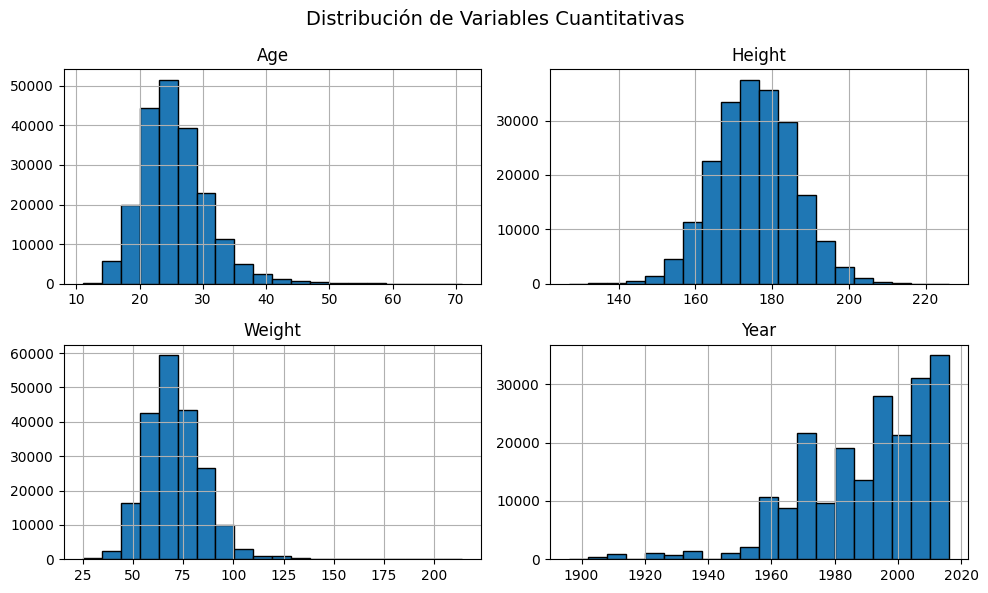

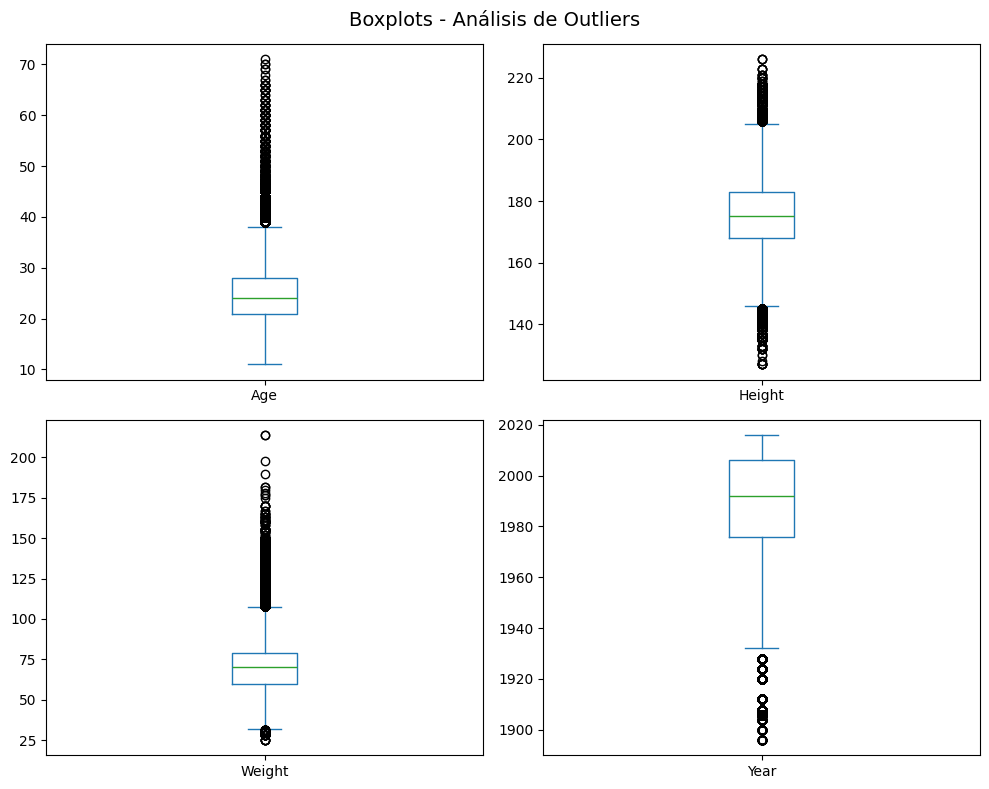

In [22]:
import matplotlib.pyplot as plt

num_vars = ['Age', 'Height', 'Weight', 'Year']

df[num_vars].hist(figsize=(10, 6), bins=20, edgecolor='black')
plt.suptitle('Distribución de Variables Cuantitativas', fontsize=14)
plt.tight_layout()
plt.show()

df[num_vars].plot(
    kind='box',
    figsize=(10, 8),
    subplots=True,
    layout=(2, 2),
    sharex=False,
    sharey=False
)
plt.suptitle('Boxplots - Análisis de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

## Análisis

### Evaluación de Normalidad
* **Height:** Es la única variable que sigue una distribución aproximadamente normal, mostrando una forma acampanada y simétrica.  
* **Age y Weight:** Presentan distribuciones asimétricas sesgadas hacia la derecha.  
* **Year:** Es una variable discreta que no sigue una distribución normal.  



### Análisis de Valores Atípicos (Outliers)
* **Age y Weight:** Presentan la mayor cantidad de valores atípicos superiores (puntos fuera del bigote superior), correspondientes a atletas de edades avanzadas o categorías de peso elevado.  
* **Height:** Muestra atípicos moderados en ambos extremos debido a deportes con requerimientos de estatura extremos (como baloncesto o gimnasia).  
* **Year:** Muestra algunos puntos aislados en las primeras ediciones olímpicas históricas.  



### Procesamiento Recomendado
* **Height, Age y Year:** Se deben incluir como características cuantitativas dentro del modelo para ayudar a predecir el peso.
* **Weight:**  No recibe procesamiento por ser la variable objetivo ($y$) que el modelo va a predecir.

---------------------

# **análisis bivariados**

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

<Figure size 700x400 with 0 Axes>

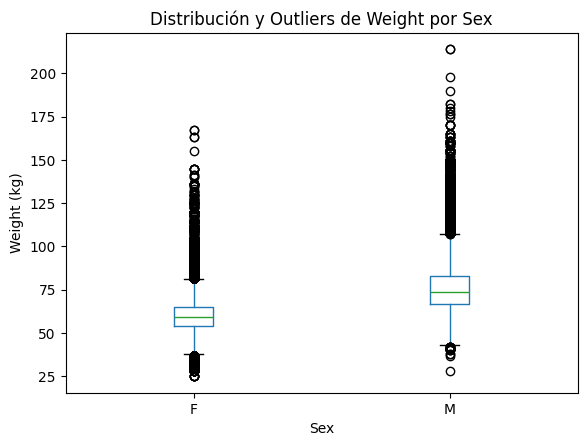

<Figure size 700x400 with 0 Axes>

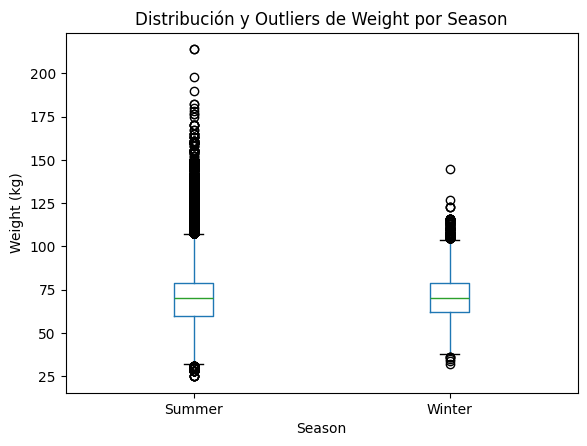

<Figure size 700x400 with 0 Axes>

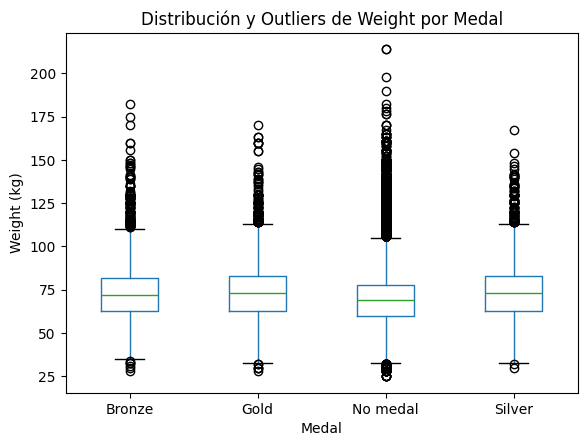

In [31]:
import matplotlib.pyplot as plt

# Variables categóricas
cat_vars = ['Sex', 'Season', 'Medal']

for var in cat_vars:
    plt.figure(figsize=(7, 4))
    df_model.boxplot(column='Weight', by=var, grid=False)
    plt.title(f'Distribución y Outliers de Weight por {var}')
    plt.suptitle('')
    plt.ylabel('Weight (kg)')
    plt.show()

## Distribución del Peso (Weight) según Variables Categóricas

* **Sex (Género):** Muestra una diferencia marcada; los hombres tienen una mediana y promedio de peso significativamente mayor ($\approx 75.8\text{ kg}$) que las mujeres ($\approx 60.0\text{ kg}$).
* **Medal (Medalla):** Quienes obtienen medalla promedian un peso ligeramente mayor ($\approx 73.5\text{ - }74.1\text{ kg}$) que quienes no ganan medalla ($\approx 70.2\text{ kg}$).
* **Season (Estación):** Las distribuciones entre Verano e Invierno son prácticamente idénticas ($\approx 70.7\text{ kg}$).

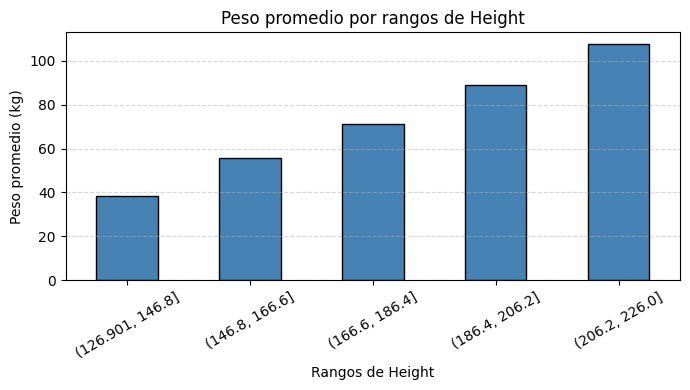

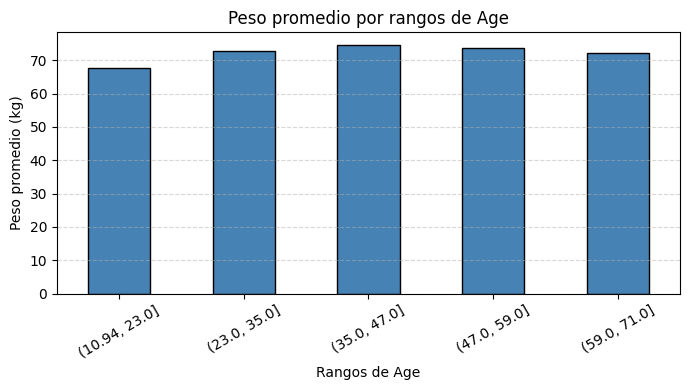

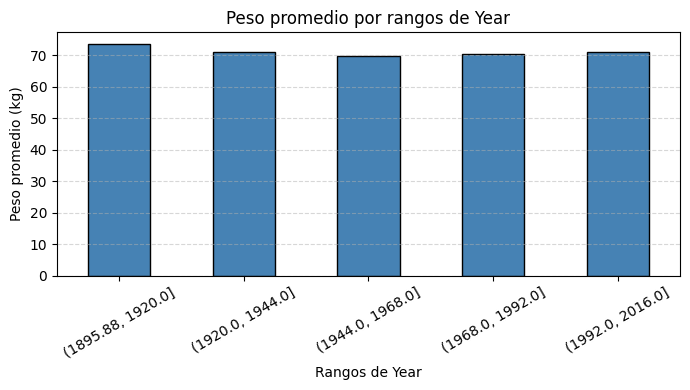

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

num_vars = ['Height', 'Age', 'Year']

for var in num_vars:
    plt.figure(figsize=(7, 4))

    df_model[f'{var}_bins'] = pd.cut(df_model[var], bins=5)

    df_model.groupby(f'{var}_bins', observed=False)['Weight'].mean().plot(kind='bar', color='steelblue', edgecolor='black')

    plt.title(f'Peso promedio por rangos de {var}')
    plt.xlabel(f'Rangos de {var}')
    plt.ylabel('Peso promedio (kg)')
    plt.xticks(rotation=30)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## Análisis del Peso Promedio según Variables Cuantitativas

* **Height (Estatura):** Presenta la relación más clara y fuerte. A mayores rangos de estatura, el peso promedio aumenta de forma directa e incremental.
* **Age (Edad):** Muestra un incremento leve en los rangos de edad jóvenes (hasta los 25 años) y luego el peso promedio se estabiliza.
* **Year (Año):** El peso promedio se mantiene constante a lo largo de los diferentes periodos de tiempo.

-----------

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión lineal USEMOS RIDGE. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge

#  Definir matriz X  y vector y
X = df_model.drop(columns=['Weight'])
y = df_model['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

#  Selección de las 5 buenas predictoras:
ordinal_cols = ['Medal']
nominal_cols = ['Sex', 'Sport']
numeric_cols = ['Height', 'Age']

# Definición del orden jerárquico para la variable ordinal
medal_categories = [['No medal', 'Bronze', 'Silver', 'Gold']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ord', OrdinalEncoder(categories=medal_categories), ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', drop='first'), nominal_cols)
    ],
    remainder='drop'
)

# Pipeline con procesamiento y modelo de Regresión Ridge
pipeline_v1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# Entrenar el modelo
pipeline_v1.fit(X_train, y_train)

# Obtener los scores R^2
train_score = pipeline_v1.score(X_train, y_train)
test_score = pipeline_v1.score(X_test, y_test)

# Obtener las características resultantes del paso de procesamiento
transformed_features = pipeline_v1.named_steps['preprocessor'].get_feature_names_out()

print(f"Score de Entrenamiento (R²): {train_score:.4f}")
print(f"Score de Prueba (R²): {test_score:.4f}")
print("\nCaracterísticas resultantes del procesamiento con las que fue entrenado el modelo:")
print(list(transformed_features))

Score de Entrenamiento (R²): 0.7298
Score de Prueba (R²): 0.7326

Características resultantes del procesamiento con las que fue entrenado el modelo:
['num__Height', 'num__Age', 'ord__Medal', 'nom__Sex_M', 'nom__Sport_Archery', 'nom__Sport_Art Competitions', 'nom__Sport_Athletics', 'nom__Sport_Badminton', 'nom__Sport_Baseball', 'nom__Sport_Basketball', 'nom__Sport_Beach Volleyball', 'nom__Sport_Biathlon', 'nom__Sport_Bobsleigh', 'nom__Sport_Boxing', 'nom__Sport_Canoeing', 'nom__Sport_Cross Country Skiing', 'nom__Sport_Curling', 'nom__Sport_Cycling', 'nom__Sport_Diving', 'nom__Sport_Equestrianism', 'nom__Sport_Fencing', 'nom__Sport_Figure Skating', 'nom__Sport_Football', 'nom__Sport_Freestyle Skiing', 'nom__Sport_Golf', 'nom__Sport_Gymnastics', 'nom__Sport_Handball', 'nom__Sport_Hockey', 'nom__Sport_Ice Hockey', 'nom__Sport_Judo', 'nom__Sport_Lacrosse', 'nom__Sport_Luge', 'nom__Sport_Modern Pentathlon', 'nom__Sport_Motorboating', 'nom__Sport_Nordic Combined', 'nom__Sport_Rhythmic Gymnast

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [39]:
# agregamos Yea a las numéricas y Season a las nominales

preprocesador_v2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Height', 'Age', 'Year']),
        ('ord', OrdinalEncoder(categories=[['No medal', 'Bronze', 'Silver', 'Gold']]), ['Medal']),
        ('nom', OneHotEncoder(drop='first'), ['Sex', 'Sport', 'Season'])
    ],
    remainder='drop'
)

modelo_v2 = Pipeline([
    ('prepro', preprocesador_v2),
    ('ridge', Ridge())
])

modelo_v2.fit(X_train, y_train)

print("Score Entrenamiento (Reentrenado):", modelo_v2.score(X_train, y_train))
print("Score Prueba (Reentrenado):", modelo_v2.score(X_test, y_test))

variables_procesadas_v2 = modelo_v2.named_steps['prepro'].get_feature_names_out()
print("\nCaracterísticas resultantes con las que realmente se reentrenó:")
print(list(variables_procesadas_v2))

Score Entrenamiento (Reentrenado): 0.7298802508610381
Score Prueba (Reentrenado): 0.7325909844962295

Características resultantes con las que realmente se reentrenó:
['num__Height', 'num__Age', 'num__Year', 'ord__Medal', 'nom__Sex_M', 'nom__Sport_Archery', 'nom__Sport_Art Competitions', 'nom__Sport_Athletics', 'nom__Sport_Badminton', 'nom__Sport_Baseball', 'nom__Sport_Basketball', 'nom__Sport_Beach Volleyball', 'nom__Sport_Biathlon', 'nom__Sport_Bobsleigh', 'nom__Sport_Boxing', 'nom__Sport_Canoeing', 'nom__Sport_Cross Country Skiing', 'nom__Sport_Curling', 'nom__Sport_Cycling', 'nom__Sport_Diving', 'nom__Sport_Equestrianism', 'nom__Sport_Fencing', 'nom__Sport_Figure Skating', 'nom__Sport_Football', 'nom__Sport_Freestyle Skiing', 'nom__Sport_Golf', 'nom__Sport_Gymnastics', 'nom__Sport_Handball', 'nom__Sport_Hockey', 'nom__Sport_Ice Hockey', 'nom__Sport_Judo', 'nom__Sport_Lacrosse', 'nom__Sport_Luge', 'nom__Sport_Modern Pentathlon', 'nom__Sport_Motorboating', 'nom__Sport_Nordic Combined'